# Step 3: Store Segmentation by Demand Shape

**Goal:** group stores by the *shape* of their demand (when they peak, how they react to
promotions, their weekly rhythm), not by size. Step 2 showed why: store 732 peaks in summer
while most stores peak in December, so one seasonal pattern will not fit every store.

**Method:** build shape features per store in SQL, standardize them, cluster with
hierarchical (Ward) clustering, pick the number of clusters, then profile each cluster.

In [1]:
import os
import warnings
import pyodbc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

warnings.filterwarnings("ignore", category=UserWarning)
sns.set_theme(style="whitegrid")

FIG_DIR = "../figures"
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs("../data/processed", exist_ok=True)

def save(name):
    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/{name}.png", dpi=150)

drivers = [d for d in pyodbc.drivers() if "ODBC Driver" in d and "SQL Server" in d]
conn = pyodbc.connect(
    f"DRIVER={{{sorted(drivers)[-1]}}};SERVER=localhost;DATABASE=RetailForecast;"
    "Trusted_Connection=yes;TrustServerCertificate=yes;"
)
print("Connected")

Connected


## 1. Build shape features in SQL

All features are **ratios to the store's own average**, so a big store and a small store with
the same pattern look identical. Only open days with sales are used (Step 1 rules).

| Feature group | Columns | What it captures |
|---|---|---|
| Monthly index | 12 | Seasonality: December peak vs. summer peak |
| Weekday index | 6 (Mon–Sat) | Weekly rhythm |
| Promo lift | 1 | Sensitivity to promotions (weekdays only) |
| School holiday lift | 1 | Sensitivity to school holidays |
| Sunday open rate | 1 | Share of Sundays the store trades |

The 180 stores with the Jul–Dec 2014 gap are included; their Jul–Dec indices rely on 2013 only.

In [2]:
OPEN = "IsOpen = 1 AND Sales > 0"

monthly = pd.read_sql(f"""
    SELECT Store, MONTH(SalesDate) AS Month, AVG(CAST(Sales AS FLOAT)) AS AvgSales
    FROM daily_sales WHERE {OPEN}
    GROUP BY Store, MONTH(SalesDate)
""", conn).pivot(index="Store", columns="Month", values="AvgSales")

weekday = pd.read_sql(f"""
    SELECT Store, DayOfWeek, AVG(CAST(Sales AS FLOAT)) AS AvgSales
    FROM daily_sales WHERE {OPEN} AND DayOfWeek <= 6
    GROUP BY Store, DayOfWeek
""", conn).pivot(index="Store", columns="DayOfWeek", values="AvgSales")

promo = pd.read_sql(f"""
    SELECT Store, CAST(Promo AS INT) AS Promo, AVG(CAST(Sales AS FLOAT)) AS AvgSales
    FROM daily_sales WHERE {OPEN} AND DayOfWeek <= 5
    GROUP BY Store, CAST(Promo AS INT)
""", conn).pivot(index="Store", columns="Promo", values="AvgSales")

school = pd.read_sql(f"""
    SELECT Store, CAST(SchoolHoliday AS INT) AS School, AVG(CAST(Sales AS FLOAT)) AS AvgSales
    FROM daily_sales WHERE {OPEN}
    GROUP BY Store, CAST(SchoolHoliday AS INT)
""", conn).pivot(index="Store", columns="School", values="AvgSales")

sunday = pd.read_sql("""
    SELECT Store, AVG(CAST(IsOpen AS FLOAT)) AS SundayOpenRate
    FROM daily_sales WHERE DayOfWeek = 7
    GROUP BY Store
""", conn).set_index("Store")

stores = pd.read_sql("SELECT Store, StoreType, Assortment FROM stores", conn).set_index("Store")

month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
day_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat"]

features = pd.concat([
    monthly.div(monthly.mean(axis=1), axis=0).set_axis(month_names, axis=1),
    weekday.div(weekday.mean(axis=1), axis=0).set_axis(day_names, axis=1),
    (promo[1] / promo[0] - 1).rename("PromoLift"),
    (school[1] / school[0] - 1).rename("SchoolLift"),
    sunday["SundayOpenRate"],
], axis=1)

print(f"Stores: {len(features):,}   Features: {features.shape[1]}")
print(f"Stores with any missing feature: {features.isna().any(axis=1).sum()}")
features.describe().T.round(2)

Stores: 1,115   Features: 21
Stores with any missing feature: 0


,count,mean,std,min,25%,50%,75%,max
Jan,1115.0,0.94,0.04,0.54,0.93,0.94,0.96,1.13
Feb,1115.0,0.94,0.04,0.58,0.93,0.94,0.96,1.13
Mar,1115.0,1.00,0.03,0.77,0.99,1.00,1.02,1.18
Apr,1115.0,1.01,0.03,0.90,1.00,1.01,1.03,1.23
May,1115.0,1.02,0.03,0.89,1.00,1.02,1.04,1.18
Jun,1115.0,1.00,0.04,0.86,0.98,1.00,1.02,1.24
Jul,1115.0,1.00,0.05,0.89,0.97,0.99,1.01,1.58
Aug,1115.0,0.95,0.06,0.81,0.92,0.94,0.97,1.53
Sep,1115.0,0.93,0.04,0.76,0.92,0.93,0.95,1.25
Oct,1115.0,0.94,0.03,0.79,0.92,0.94,0.96,1.20


**Note:**All 1,115 stores have complete features, so no imputation was needed. December is the strongest month for most stores (average index 1.23), but some peak in summer (July index up to 1.58). Saturday varies most across stores (index 0.32–1.39), promo lift ranges from +2% to +102%, and 75% of stores never open on Sundays.

In [3]:
# Fill any gaps with the column median so every store gets a cluster, then standardize
X = features.fillna(features.median())
X_scaled = StandardScaler().fit_transform(X)

## 2. Hierarchical clustering

Ward linkage merges the two groups that increase within-cluster variance the least at each step.
The dendrogram shows how stores merge; long vertical lines mean well-separated groups.

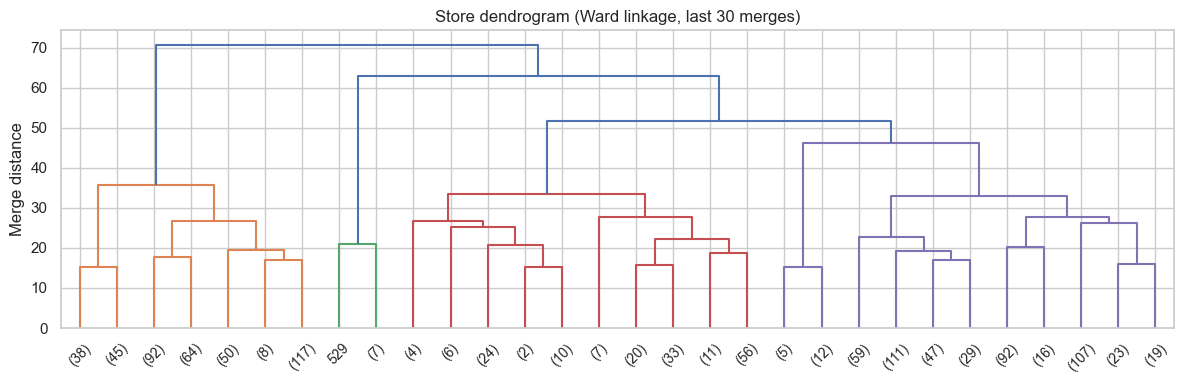

In [4]:
Z = linkage(X_scaled, method="ward")

fig, ax = plt.subplots(figsize=(12, 4))
dendrogram(Z, truncate_mode="lastp", p=30, ax=ax, color_threshold=None)
ax.set_title("Store dendrogram (Ward linkage, last 30 merges)")
ax.set_ylabel("Merge distance")
save("07_dendrogram")
plt.show()

## 3. Choose the number of clusters

Silhouette score (higher is better) measures how well each store fits its own cluster vs. the
nearest other one. Use it together with the dendrogram and with whether the clusters make
business sense; the highest score is not automatically the right answer.

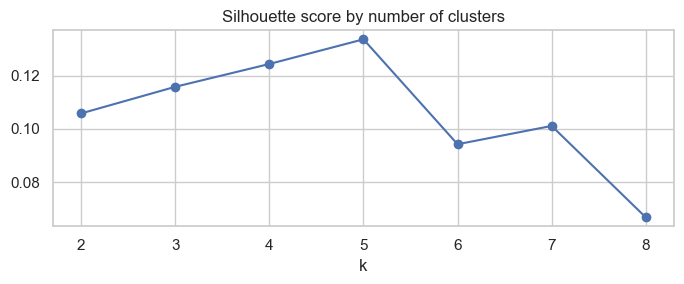

2    0.106
3    0.116
4    0.124
5    0.134
6    0.094
7    0.101
8    0.067
Name: Silhouette, dtype: float64

In [5]:
scores = {k: silhouette_score(X_scaled, fcluster(Z, k, criterion="maxclust")) for k in range(2, 9)}
sil = pd.Series(scores, name="Silhouette")

fig, ax = plt.subplots(figsize=(7, 3))
sil.plot(marker="o", ax=ax)
ax.set_title("Silhouette score by number of clusters")
ax.set_xlabel("k")
save("08_silhouette")
plt.show()

sil.round(3)

In [6]:
K = 5  
features["Cluster"] = fcluster(Z, K, criterion="maxclust")
profile = features.join(stores)
print(profile["Cluster"].value_counts().sort_index().rename("Stores"))

Cluster
1    414
2      8
3    173
4     17
5    503
Name: Stores, dtype: int64


## 4. Profile the clusters

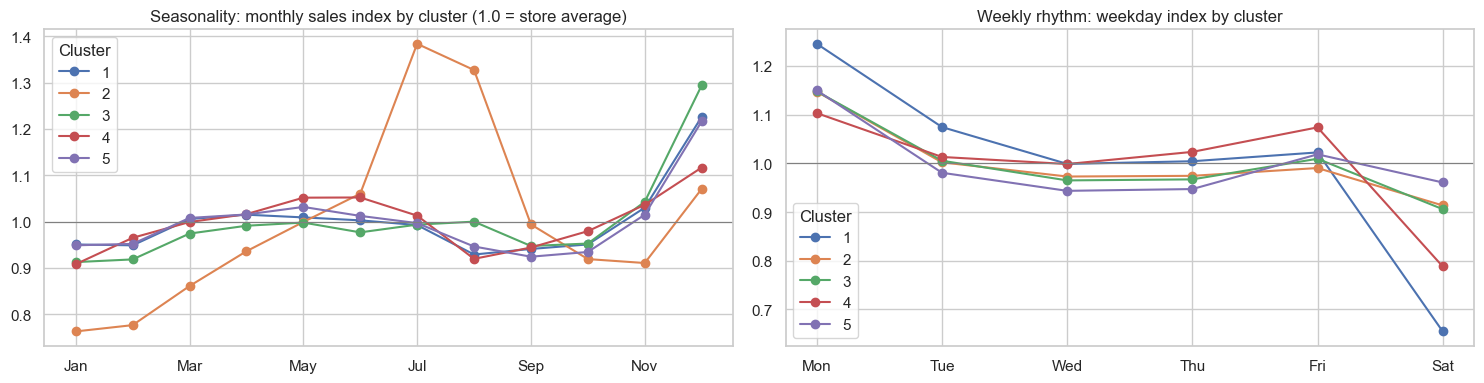

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

profile.groupby("Cluster")[month_names].mean().T.plot(marker="o", ax=axes[0])
axes[0].axhline(1, color="grey", lw=0.8)
axes[0].set_title("Seasonality: monthly sales index by cluster (1.0 = store average)")

profile.groupby("Cluster")[day_names].mean().T.plot(marker="o", ax=axes[1])
axes[1].axhline(1, color="grey", lw=0.8)
axes[1].set_title("Weekly rhythm: weekday index by cluster")

save("09_cluster_profiles")
plt.show()

In [8]:
summary = profile.groupby("Cluster").agg(
    Stores=("Dec", "size"),
    DecIndex=("Dec", "mean"),
    JulAugIndex=("Jul", lambda s: profile.loc[s.index, ["Jul", "Aug"]].mean(axis=1).mean()),
    PromoLift=("PromoLift", "mean"),
    SchoolLift=("SchoolLift", "mean"),
    SundayOpenRate=("SundayOpenRate", "mean"),
)
display(summary.round(2))

print("Store type mix by cluster (% of cluster):")
display((pd.crosstab(profile["Cluster"], profile["StoreType"], normalize="index") * 100).round(0))

,Stores,DecIndex,JulAugIndex,PromoLift,SchoolLift,SundayOpenRate
Cluster,,,,,,
1,414,1.23,0.96,0.43,0.06,0.00
2,8,1.07,1.36,0.21,0.40,0.69
3,173,1.29,1.00,0.35,0.07,0.03
4,17,1.12,0.97,0.20,-0.02,0.98
5,503,1.22,0.97,0.40,0.02,0.00


Store type mix by cluster (% of cluster):


StoreType,a,b,c,d
Cluster,,,,
1,78.0,0.0,6.0,15.0
2,75.0,0.0,0.0,25.0
3,60.0,0.0,23.0,17.0
4,0.0,100.0,0.0,0.0
5,33.0,0.0,16.0,50.0


**Cluster descriptions (k = 5):**
1. **Weekday-focused, promo-sensitive (414 stores):** strong Mondays, very weak Saturdays (index 0.65), highest promo lift (+43%); likely office or commuter areas.
2. **Summer / tourist (8 stores):** peak in July–August (index 1.36), weak winters, +40% during school holidays, open most Sundays.
3. **Christmas-driven (173 stores):** strongest December peak (index 1.29) with an otherwise typical pattern.
4. **Sunday-trading, high-traffic (17 stores):** exactly the 17 type b stores; open nearly every Sunday, lowest promo sensitivity (+20%), steady year-round demand.
5. **Balanced week (503 stores):** strong Saturdays (index 0.96), typical December and promo response; likely residential shopping areas.

## 5. Where do the sample stores fall?

In [9]:
sample = pd.read_csv("../data/processed/sample_stores.csv")
sample["Cluster"] = sample["Store"].map(features["Cluster"])
sample

,Store,StoreType,WeeklySales,Cluster
0,732,a,38042.157895,2
1,423,b,75840.503759,4
2,504,c,38864.571429,5
3,352,d,38976.684211,5


In [11]:
# Re-pick the deep-dive sample: the complete store closest to each cluster's center
complete = set(pd.read_sql(
    "SELECT Store FROM daily_sales GROUP BY Store HAVING COUNT(*) = 942", conn)["Store"])
Xs = pd.DataFrame(X_scaled, index=features.index)

reps = []
for c, members in features.groupby("Cluster").groups.items():
    candidates = [s for s in members if s in complete] or list(members)
    dist = ((Xs.loc[candidates] - Xs.loc[members].mean()) ** 2).sum(axis=1)
    reps.append((dist.idxmin(), c))

sample = pd.DataFrame(reps, columns=["Store", "Cluster"]).join(stores, on="Store")
sample.to_csv("../data/processed/sample_stores.csv", index=False)
sample

,Store,Cluster,StoreType,Assortment
0,314,1,a,a
1,299,2,d,c
2,763,3,d,c
3,259,4,b,b
4,640,5,d,c


**Note:** The Step 2 sample (chosen by store type) covered only 3 of the 5 demand clusters. The sample was re-picked as the complete-history store closest to each cluster's center, so every demand pattern is tested in the forecasting steps.

## 6. Save cluster labels

In [12]:
features[["Cluster"]].reset_index().to_csv("../data/processed/store_clusters.csv", index=False)

# Also store in SQL Server so Tableau and later steps can join on it
cur = conn.cursor()
cur.execute("DROP TABLE IF EXISTS store_clusters")
cur.execute("CREATE TABLE store_clusters (Store INT NOT NULL PRIMARY KEY, Cluster INT NOT NULL)")
cur.fast_executemany = True
cur.executemany("INSERT INTO store_clusters (Store, Cluster) VALUES (?, ?)",
                [(int(s), int(c)) for s, c in features["Cluster"].items()])
conn.commit()
print(pd.read_sql("SELECT Cluster, COUNT(*) AS Stores FROM store_clusters GROUP BY Cluster", conn))

   Cluster  Stores
0        3     173
1        1     414
2        4      17
3        5     503
4        2       8


## Summary of findings

- **Five demand patterns** emerged from 21 shape features (hierarchical clustering, Ward linkage). k = 5 had the best silhouette score (0.134) and every cluster had a clear business meaning.
- **Weekday vs. Saturday is the main divide:** 917 of 1,115 stores split into weekday-focused stores (weak Saturdays, index 0.65, most promo-sensitive at +43%) and balanced-week stores (strong Saturdays, index 0.96).
- **Clustering independently identified all 17 type b stores** from sales patterns alone: Sunday-trading, high-traffic locations with the lowest promo sensitivity (+20%).
- **A small summer/tourist group (8 stores)** peaks in July–August and gains 40% during school holidays, the opposite of the chain's December peak.
- **Implications for forecasting:** low silhouette scores mean stores sit on a continuum, so cluster labels will be used as a model feature rather than building separate models per cluster. The deep-dive sample was re-picked with one typical store per cluster.

In [13]:
conn.close()